In [7]:
import torch
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='data/Cora', name='Cora')

data = dataset[0]

print(f"Количество классов (тем статей): {dataset.num_classes}")
print(f"Количество признаков (длина словаря): {dataset.num_node_features}")
print("---")
print("Сам граф:")
data

Количество классов (тем статей): 7
Количество признаков (длина словаря): 1433
---
Сам граф:


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [8]:
dataset.num_classes

7

In [9]:
data.x

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [12]:
data.x.shape

torch.Size([2708, 1433])

In [10]:
data.edge_index

tensor([[ 633, 1862, 2582,  ...,  598, 1473, 2706],
        [   0,    0,    0,  ..., 2707, 2707, 2707]])

In [11]:
data.y

tensor([3, 4, 4,  ..., 3, 3, 3])

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [18]:
data.to(device)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [16]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = GCN(num_node_features=dataset.num_node_features, num_classes=dataset.num_classes).to(device)

In [20]:
# 1. Настройки оптимизатора (Adam - наш лучший друг)
# weight_decay - это L2-регуляризация, спасает от переобучения
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Переводим всё на видеокарту (если есть)
data = data.to(device)
model.train()

epochs = 200 # Для GNN часто нужно чуть больше эпох, они быстрые

for epoch in range(epochs):
    optimizer.zero_grad()

    # 2. ПРЯМОЙ ПРОХОД: Закидываем ВЕСЬ граф целиком
    out = model(data)

    # 3. СЧИТАЕМ ОШИБКУ (LOSS) ТОЛЬКО ДЛЯ ТРЕНИРОВОЧНЫХ УЗЛОВ!
    # Наш выход out имеет размер [2708, 7].
    # out[data.train_mask] вырежет оттуда только те 140 строк, на которых мы учимся.
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    # 4. ОБРАТНЫЙ ПРОХОД (Градиенты текут по связям!)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f'Эпоха: {epoch:03d}, Loss: {loss:.4f}')

print("Обучение завершено!")

Эпоха: 000, Loss: 1.9585
Эпоха: 020, Loss: 0.1443
Эпоха: 040, Loss: 0.0250
Эпоха: 060, Loss: 0.0188
Эпоха: 080, Loss: 0.0225
Эпоха: 100, Loss: 0.0200
Эпоха: 120, Loss: 0.0164
Эпоха: 140, Loss: 0.0187
Эпоха: 160, Loss: 0.0151
Эпоха: 180, Loss: 0.0135
Обучение завершено!


In [21]:
# Переводим модель в режим оценки (отключаем Dropout)
model.eval()

# Делаем финальное предсказание (градиенты больше не нужны)
with torch.no_grad():
    out = model(data)

    # argmax(dim=1) берет индекс максимальной вероятности (наш предсказанный класс)
    pred = out.argmax(dim=1)

    # Сравниваем предсказания с реальными ответами, НО ТОЛЬКО для тестовой маски
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()

    # Считаем процент правильных ответов
    test_acc = int(correct) / int(data.test_mask.sum())

    print(f'Точность на тестовой выборке: {test_acc:.4f} ({test_acc * 100:.2f}%)')

Точность на тестовой выборке: 0.8050 (80.50%)


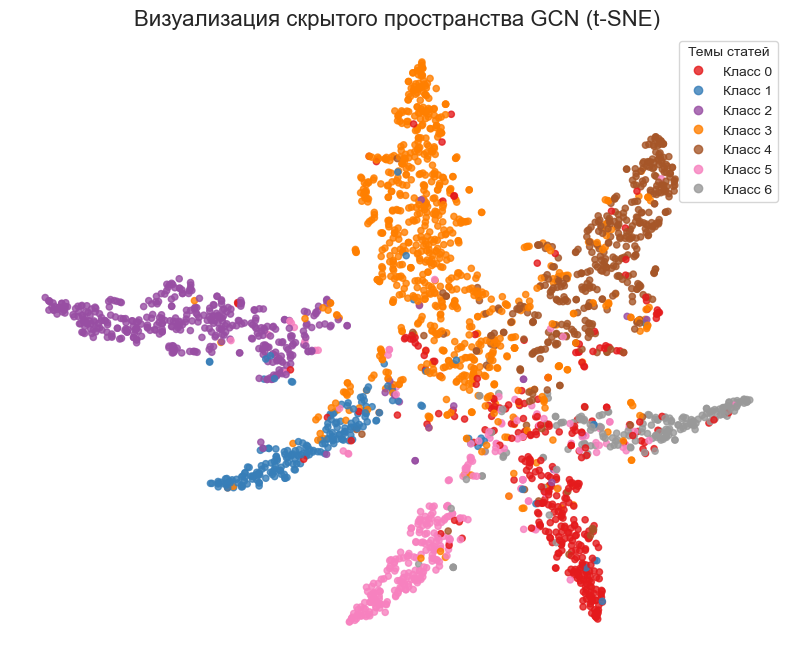

In [23]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Берем выходы нейросети (логиты)
model.eval()
with torch.no_grad():
    out = model(data).cpu().numpy()

# Сжимаем 7 мерное пространство в 2D для отрисовки
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(out)

# Рисуем точки, раскрашивая их в реальные цвета классов
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=data.y.cpu().numpy(), cmap='Set1', s=20, alpha=0.8)

plt.title("Визуализация скрытого пространства GCN (t-SNE)", fontsize=16)
plt.legend(handles=scatter.legend_elements()[0],
           labels=[f"Класс {i}" for i in range(dataset.num_classes)],
           title="Темы статей")
plt.axis('off')
plt.show()